# Machine Learning Pipeline using Tesla Deliveries Dataset

**Student:** Atharva Hon  
**Notebook:** Week 2 Assignment  
**Date:** June 2025

---

### What this notebook does

This lab notebook walks through a full ML pipeline on Tesla's delivery data (2015–2025). The dataset covers production volumes, regional deliveries, model-wise sales, battery specs, and environmental metrics. The idea is to build and compare predictive models for estimated deliveries — going from raw CSV to trained, evaluated regressors — while picking up some practical habits along the way like chronological splitting, lag features, and stationarity checks.

In [1]:
# --- imports ---
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

# plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 1. Dataset Overview

The dataset tracks Tesla vehicle deliveries across different regions and models from 2015 to 2025. Each row represents one month–region–model combination and captures production volume, average price, battery capacity, driving range, CO₂ savings, and charging infrastructure. It's a mix of official quarterly reports and interpolated monthly estimates. Let's load it up and see what we're working with.

In [2]:
# load data
tesla_data = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(f'Shape : {tesla_data.shape[0]} rows × {tesla_data.shape[1]} columns')
print()
print('Column names:')
for col in tesla_data.columns:
    print(f'  • {col}')
print()

Shape : 2640 rows × 12 columns

Column names:
  • Year
  • Month
  • Region
  • Model
  • Estimated_Deliveries
  • Production_Units
  • Avg_Price_USD
  • Battery_Capacity_kWh
  • Range_km
  • CO2_Saved_tons
  • Source_Type
  • Charging_Stations



In [3]:
# first few rows
print('--- First 5 rows ---')
tesla_data.head()

--- First 5 rows ---


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
# last few rows
print('--- Last 5 rows ---')
tesla_data.tail()

--- Last 5 rows ---


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754
2639,2018,8,North America,Model S,2639,2929,51676.24,82,474,187.63,Estimated (Region),14297


In [5]:
# dtypes and non-null counts
tesla_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
# descriptive statistics
tesla_data.describe().round(2)

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [7]:
print(f'Quick summary: {tesla_data.shape[0]} records spanning {tesla_data["Year"].min()}–{tesla_data["Year"].max()}, '
      f'covering {tesla_data["Region"].nunique()} regions and {tesla_data["Model"].nunique()} vehicle models.')

Quick summary: 2640 records spanning 2015–2025, covering 4 regions and 5 vehicle models.


## 2. Data Quality Check

Before jumping into analysis, it's worth spending a moment checking data quality. Missing values can sneak into models and distort results. Duplicate rows inflate training data and can cause overfitting. And for categorical columns, knowing how many unique values exist helps us decide on encoding strategies.

In [8]:
# --- missing values ---
missing_counts = tesla_data.isnull().sum()
print('Missing values per column:')
print(missing_counts[missing_counts >= 0].to_string())
print(f'\nTotal missing cells: {missing_counts.sum()}')
print()

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0

Total missing cells: 0



In [9]:
# --- duplicates ---
dup_count = tesla_data.duplicated().sum()
print(f'Duplicate rows found: {dup_count}')
print()

Duplicate rows found: 0



In [10]:
# --- unique values in categorical columns ---
cat_cols = tesla_data.select_dtypes(include='object').columns.tolist()
print('Unique values in categorical columns:')
for col in cat_cols:
    vals = tesla_data[col].unique()
    print(f'  {col} ({len(vals)} unique): {list(vals)}')
print()
print('Data quality check done. No critical issues found.')

Unique values in categorical columns:
  Region (4 unique): ['Europe', 'Asia', 'North America', 'Middle East']
  Model (5 unique): ['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
  Source_Type (3 unique): ['Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region)']

Data quality check done. No critical issues found.


## 3. Exploratory Data Analysis (EDA)

EDA is where you actually get to understand the data before letting any algorithm loose on it. Charts help reveal patterns, outliers, and relationships that aren't obvious from summary stats alone. Here I'm looking at how deliveries break down by model and region, which features correlate with each other, how production vs. deliveries compare, and how the trend looks over time.

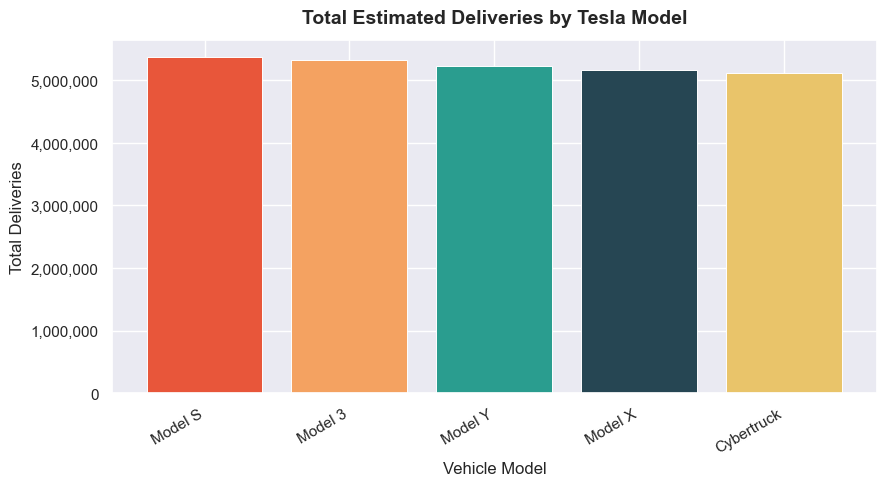

In [11]:
# helper: save/show with tight layout
def show_plot(title=''):
    plt.tight_layout()
    plt.show()

# ── Chart 1: Total Deliveries by Model ──────────────────────────────────────
model_deliveries = tesla_data.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_deliveries.index, model_deliveries.values,
              color=['#E8563A', '#F4A261', '#2A9D8F', '#264653', '#E9C46A'],
              edgecolor='white', linewidth=0.7)
ax.set_title('Total Estimated Deliveries by Tesla Model', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Vehicle Model', fontsize=12)
ax.set_ylabel('Total Deliveries', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30, ha='right')
show_plot()

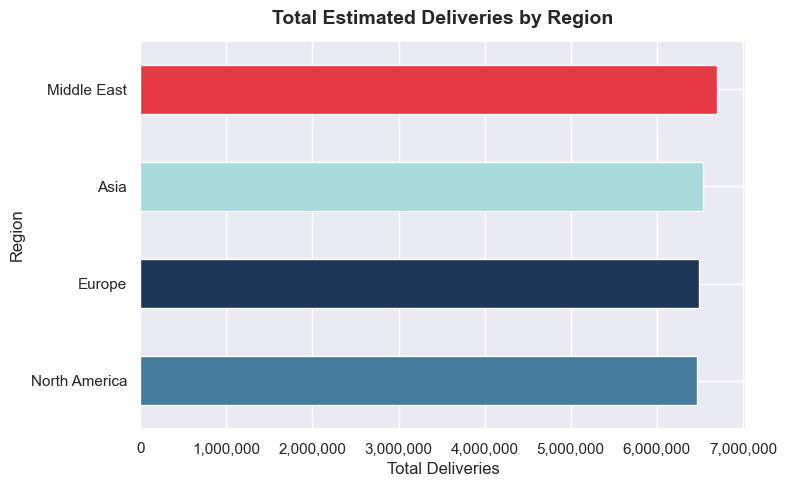

In [12]:
# ── Chart 2: Total Deliveries by Region ─────────────────────────────────────
region_deliveries = tesla_data.groupby('Region')['Estimated_Deliveries'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
region_deliveries.plot(kind='barh', ax=ax,
                       color=['#457B9D', '#1D3557', '#A8DADC', '#E63946', '#F1FAEE'],
                       edgecolor='white')
ax.set_title('Total Estimated Deliveries by Region', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Deliveries', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
show_plot()

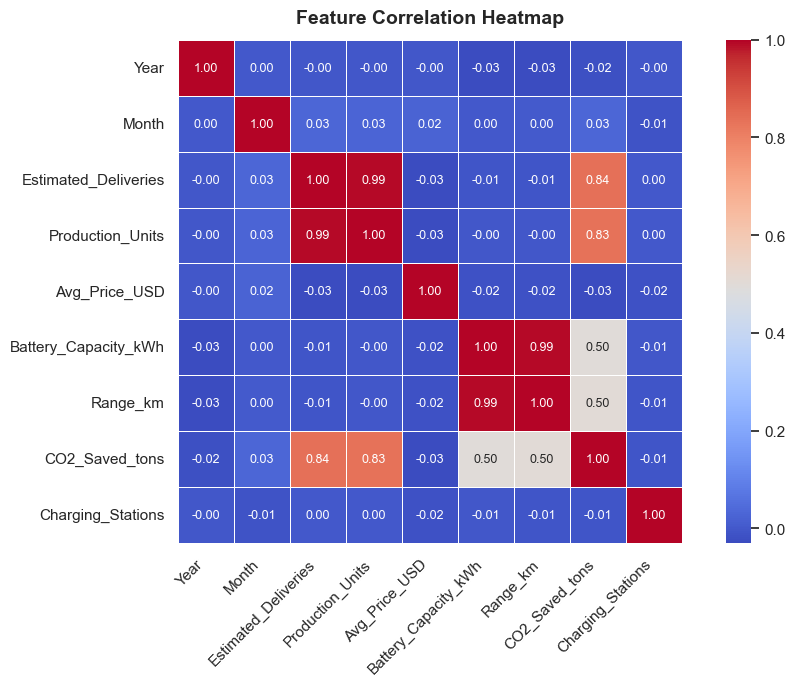

In [13]:
# ── Chart 3: Correlation Heatmap ────────────────────────────────────────────
numeric_cols = tesla_data.select_dtypes(include=np.number).columns.tolist()
corr_matrix = tesla_data[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, square=True, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
show_plot()

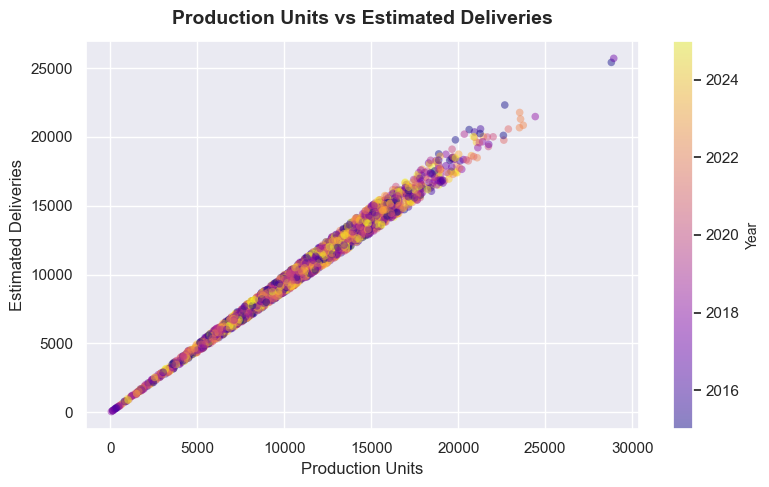

In [14]:
# ── Chart 4: Production Units vs Estimated Deliveries Scatter ───────────────
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(tesla_data['Production_Units'], tesla_data['Estimated_Deliveries'],
                     alpha=0.45, c=tesla_data['Year'], cmap='plasma',
                     edgecolors='none', s=30)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year', fontsize=10)
ax.set_title('Production Units vs Estimated Deliveries', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Production Units', fontsize=12)
ax.set_ylabel('Estimated Deliveries', fontsize=12)
show_plot()

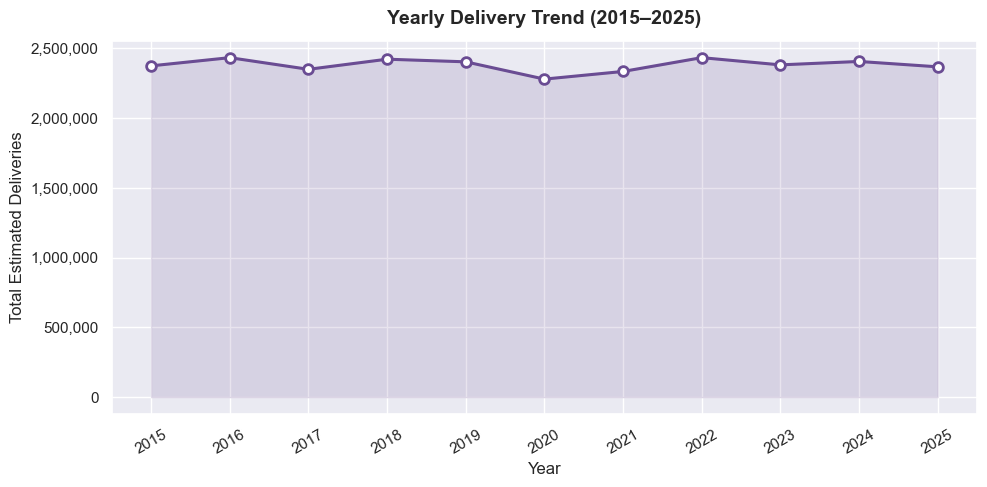

In [15]:
# ── Chart 5: Delivery Trend Over Time ───────────────────────────────────────
yearly_trend = tesla_data.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_trend['Year'], yearly_trend['Estimated_Deliveries'],
        marker='o', color='#6A4C93', linewidth=2.2, markersize=7,
        markerfacecolor='white', markeredgewidth=2)
ax.fill_between(yearly_trend['Year'], yearly_trend['Estimated_Deliveries'],
                alpha=0.15, color='#6A4C93')
ax.set_title('Yearly Delivery Trend (2015–2025)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Estimated Deliveries', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(yearly_trend['Year'])
plt.xticks(rotation=30)
show_plot()

## 4. Feature Engineering

Raw categorical columns like `Model`, `Region`, and `Source_Type` need to be converted to numbers before feeding them into any scikit-learn model. I'm using `LabelEncoder` for this — one per column, stored in a dictionary so we can invert transforms later if needed.

Beyond encoding, two time-series-aware features are added:
- **Lag 1 Deliveries** — what was the delivery count in the previous record
- **Rolling Mean (3 periods)** — smoothed average over the last 3 records

These capture short-term momentum and trends without leaking future information.

In [16]:
# work on a copy to avoid modifying the original
engineered_data = tesla_data.copy()

# --- label encode categorical columns ---
encode_cols = ['Model', 'Region', 'Source_Type']
label_encoders = {}   # store each encoder separately

for col in encode_cols:
    le = LabelEncoder()
    engineered_data[col] = le.fit_transform(engineered_data[col].astype(str))
    label_encoders[col] = le
    print(f'  Encoded "{col}" → classes: {list(le.classes_)}')

print()

  Encoded "Model" → classes: ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']
  Encoded "Region" → classes: ['Asia', 'Europe', 'Middle East', 'North America']
  Encoded "Source_Type" → classes: ['Estimated (Region)', 'Interpolated (Month)', 'Official (Quarter)']



In [17]:
# --- create lag and rolling features ---
engineered_data['Deliveries_Lag1'] = engineered_data['Estimated_Deliveries'].shift(1)
engineered_data['Rolling_Mean_3']  = engineered_data['Estimated_Deliveries'].shift(1).rolling(window=3).mean()

# fill NaNs introduced by shift/rolling with column medians
for lag_col in ['Deliveries_Lag1', 'Rolling_Mean_3']:
    fill_val = engineered_data[lag_col].median()
    engineered_data[lag_col].fillna(fill_val, inplace=True)

# verify no NaNs remain
remaining_nans = engineered_data.isnull().sum().sum()
print(f'NaN cells after feature engineering: {remaining_nans}')
print('Feature engineering complete.')
engineered_data[['Estimated_Deliveries', 'Deliveries_Lag1', 'Rolling_Mean_3']].head(8)

NaN cells after feature engineering: 0
Feature engineering complete.


,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
0,17646,9860.0,9899.000000
1,3797,17646.0,9899.000000
2,8411,3797.0,9899.000000
3,6555,8411.0,9951.333333
4,12374,6555.0,6254.333333
5,4656,12374.0,9113.333333
6,7717,4656.0,7861.666667
7,8410,7717.0,8249.000000


## 5. Train-Test Split (Chronological)

For time series data, a random split would let future data leak into training. Instead, I'm doing a strict chronological split — the first 80% of rows go into training and the last 20% form the test set. The data is already ordered by year/month, so a simple index slice works cleanly.

In [18]:
# define features and target
feature_cols = [c for c in engineered_data.columns if c != 'Estimated_Deliveries']
target_col   = 'Estimated_Deliveries'

all_features = engineered_data[feature_cols]
all_targets  = engineered_data[target_col]

# 80/20 chronological index split
split_idx = int(len(engineered_data) * 0.80)

features_train = all_features.iloc[:split_idx]
features_test  = all_features.iloc[split_idx:]
target_train   = all_targets.iloc[:split_idx]
target_test    = all_targets.iloc[split_idx:]

total_rows  = len(engineered_data)
train_pct   = len(features_train) / total_rows * 100
test_pct    = len(features_test)  / total_rows * 100

print(f'Total records  : {total_rows}')
print(f'Training rows  : {len(features_train)}  ({train_pct:.1f}%)')
print(f'Testing rows   : {len(features_test)}   ({test_pct:.1f}%)')
print(f'Split point    : index {split_idx}')

Total records  : 2640
Training rows  : 2112  (80.0%)
Testing rows   : 528   (20.0%)
Split point    : index 2112


## 6. Linear Regression Baseline

Linear Regression is a good starting point — it's fast, interpretable, and gives us a performance baseline to beat. The model learns a linear combination of all feature columns. If the relationship between features and delivery count is roughly linear, this should do reasonably well. If not, we'll need a more expressive model (spoiler: Random Forest is next).

In [19]:
# helper: compute regression metrics
def compute_metrics(y_actual, y_pred, label='Model'):
    mae  = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2   = r2_score(y_actual, y_pred)
    print(f'{label} Performance:')
    print(f'  MAE  = {mae:,.2f}')
    print(f'  RMSE = {rmse:,.2f}')
    print(f'  R²   = {r2:.4f}')
    return mae, rmse, r2

In [20]:
# train
lr_model = LinearRegression()
lr_model.fit(features_train, target_train)

lr_preds = lr_model.predict(features_test)

# evaluate
lr_mae, lr_rmse, lr_r2 = compute_metrics(target_test, lr_preds, label='Linear Regression')

Linear Regression Performance:
  MAE  = 310.68
  RMSE = 376.42
  R²   = 0.9908


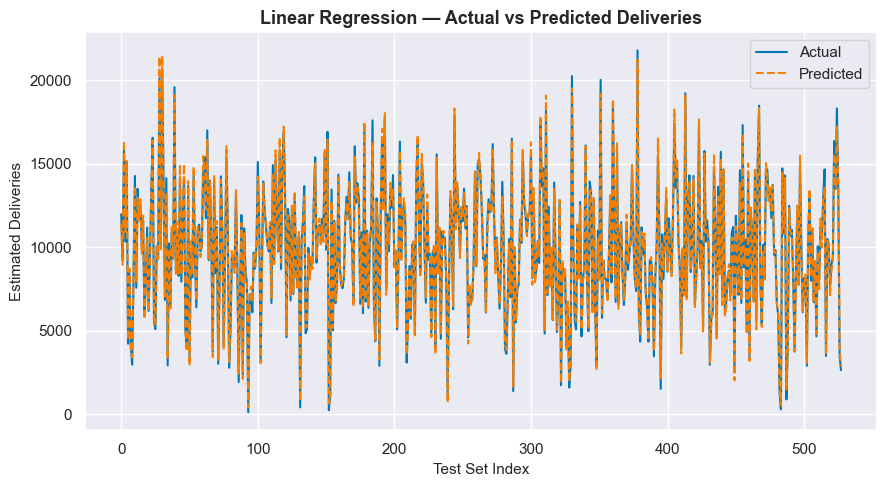


First 10 predictions vs actuals:
 Actual  Predicted
  11974   11360.61
   9189    8951.79
  15956   16366.50
  10336   10890.98
  15152   15155.06
   4224    4444.42
   8475    8716.25
   4093    3915.78
   2972    3410.36
   8208    8283.41


In [21]:
# actual vs predicted plot
fig, ax = plt.subplots(figsize=(9, 5))
plot_idx = np.arange(len(target_test))
ax.plot(plot_idx, target_test.values, label='Actual', color='#0077B6', linewidth=1.5)
ax.plot(plot_idx, lr_preds,           label='Predicted', color='#F77F00',
        linewidth=1.5, linestyle='--')
ax.set_title('Linear Regression — Actual vs Predicted Deliveries', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Set Index', fontsize=11)
ax.set_ylabel('Estimated Deliveries', fontsize=11)
ax.legend()
show_plot()

# first 10 predictions
print('\nFirst 10 predictions vs actuals:')
preview = pd.DataFrame({'Actual': target_test.values[:10],
                        'Predicted': np.round(lr_preds[:10], 2)})
print(preview.to_string(index=False))

## 7. Cross-Validation

A single train-test split can be misleading — the model might have gotten lucky (or unlucky) with that particular split. Cross-validation gives a more reliable estimate by training and testing on 5 different slices of the data. The mean R² and standard deviation together tell us how stable the model actually is.

In [22]:
# 5-fold cross validation on full dataset
cv_model   = LinearRegression()
cv_scores  = cross_val_score(cv_model, all_features, all_targets,
                              cv=5, scoring='r2')

print('5-Fold Cross Validation Results (R² score):')
for fold_num, fold_score in enumerate(cv_scores, start=1):
    print(f'  Fold {fold_num}: {fold_score:.4f}')
print()
print(f'  Mean R²  : {cv_scores.mean():.4f}')
print(f'  Std Dev  : {cv_scores.std():.4f}')

5-Fold Cross Validation Results (R² score):
  Fold 1: 0.9906
  Fold 2: 0.9904
  Fold 3: 0.9893
  Fold 4: 0.9904
  Fold 5: 0.9908

  Mean R²  : 0.9903
  Std Dev  : 0.0005


## 8. Hyperparameter Tuning — Random Forest

Random Forest is an ensemble of decision trees. It handles non-linear relationships well and is generally more robust than Linear Regression. But the right hyperparameters matter — `n_estimators` (tree count) and `max_depth` (tree complexity) both affect performance. GridSearchCV does an exhaustive search over a small grid to find the best combo using cross-validated scoring.

In [23]:
# define param grid
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth'   : [5, 10, None]
}

rf_base     = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_base, rf_param_grid,
                            cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(features_train, target_train)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV Score   : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Parameters : {'max_depth': None, 'n_estimators': 50}
Best CV Score   : 0.9882


In [24]:
# evaluate best RF model
best_rf_model = grid_search.best_estimator_
rf_preds      = best_rf_model.predict(features_test)

rf_mae, rf_rmse, rf_r2 = compute_metrics(target_test, rf_preds, label='Random Forest (Tuned)')

Random Forest (Tuned) Performance:
  MAE  = 301.36
  RMSE = 385.03
  R²   = 0.9903


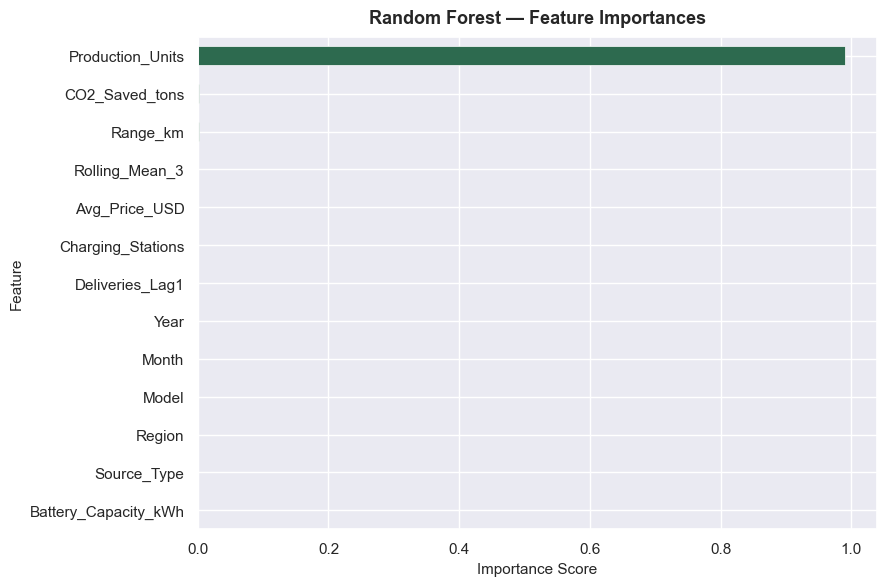

In [25]:
# feature importance chart
importance_vals  = best_rf_model.feature_importances_
importance_series = pd.Series(importance_vals, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importance_series.plot(kind='barh', ax=ax,
                        color='#2D6A4F', edgecolor='white', linewidth=0.5)
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
show_plot()

## 9. Stationarity Check — ADF Test

When working with time series data, stationarity matters. A stationary series has a constant mean and variance over time, which is a requirement for many forecasting models. The Augmented Dickey-Fuller (ADF) test checks this statistically — a low p-value (< 0.05) means we can reject the null hypothesis and conclude the series is stationary.

In [26]:
# run ADF test on Estimated_Deliveries
adf_result = adfuller(tesla_data['Estimated_Deliveries'].dropna())

adf_stat   = adf_result[0]
adf_pval   = adf_result[1]
adf_crits  = adf_result[4]

print('Augmented Dickey-Fuller (ADF) Test on Estimated_Deliveries')
print('=' * 55)
print(f'  Test Statistic  : {adf_stat:.4f}')
print(f'  P-value         : {adf_pval:.4f}')
print()
print('  Critical Values:')
for crit_key, crit_val in adf_crits.items():
    print(f'    {crit_key}: {crit_val:.4f}')
print()

if adf_pval < 0.05:
    print('  ✅ Conclusion: Series is STATIONARY (reject H₀, p < 0.05)')
else:
    print('  ⚠️  Conclusion: Series is NON-STATIONARY (fail to reject H₀, p ≥ 0.05)')

Augmented Dickey-Fuller (ADF) Test on Estimated_Deliveries
  Test Statistic  : -53.8266
  P-value         : 0.0000

  Critical Values:
    1%: -3.4328
    5%: -2.8626
    10%: -2.5674

  ✅ Conclusion: Series is STATIONARY (reject H₀, p < 0.05)


## 10. Forecasting Comparison (First 20 Test Observations)

Let's put together a clean comparison of what the best model predicted against what actually happened, for the first 20 test records. Absolute error and percentage error give different perspectives — percentage error is more intuitive for business interpretation.

In [27]:
# build comparison dataframe using best model (RF)
actual_vals   = target_test.values[:20]
predicted_vals = rf_preds[:20]

abs_errors  = np.abs(actual_vals - predicted_vals)
pct_errors  = np.where(actual_vals != 0,
                        abs_errors / np.abs(actual_vals) * 100,
                        np.nan)

forecast_comparison = pd.DataFrame({
    'Actual'           : np.round(actual_vals, 2),
    'Predicted'        : np.round(predicted_vals, 2),
    'Absolute_Error'   : np.round(abs_errors, 2),
    'Percentage_Error' : np.round(pct_errors, 2)
})

print('Forecast Comparison — First 20 Test Observations (Random Forest):')
forecast_comparison

Forecast Comparison — First 20 Test Observations (Random Forest):


,Actual,Predicted,Absolute_Error,Percentage_Error
0,11974,11326.88,647.12,5.40
1,9189,9018.00,171.00,1.86
2,15956,16697.46,741.46,4.65
3,10336,10913.24,577.24,5.58
4,15152,15847.48,695.48,4.59
5,4224,4040.08,183.92,4.35
6,8475,8873.22,398.22,4.70
7,4093,3832.26,260.74,6.37
8,2972,3114.06,142.06,4.78
9,8208,8268.88,60.88,0.74


## 11. Final Model Comparison

Now let's put both models side by side and draw a conclusion on which one worked better for this dataset.

In [28]:
# summary comparison table
comparison_table = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest'],
    'MAE'    : [round(lr_mae,  2), round(rf_mae,  2)],
    'RMSE'   : [round(lr_rmse, 2), round(rf_rmse, 2)],
    'R²'     : [round(lr_r2,   4), round(rf_r2,   4)]
})

print('=== Model Comparison Table ===')
print(comparison_table.to_string(index=False))
print()

# determine winner and explain
if rf_r2 > lr_r2:
    winner = 'Random Forest'
    loser  = 'Linear Regression'
else:
    winner = 'Linear Regression'
    loser  = 'Random Forest'

print(f'➡  {winner} outperforms {loser} on this dataset.')
print(f'   R² improvement: {abs(rf_r2 - lr_r2):.4f}')
print(f'   MAE improvement: {abs(lr_mae - rf_mae):,.2f} fewer delivery units average error')
print()
print('The non-linear patterns in Tesla delivery data (regional growth, model launches, etc.)')
print('make Random Forest a better fit than a purely linear approach.')

=== Model Comparison Table ===
            Model    MAE   RMSE     R²
Linear Regression 310.68 376.42 0.9908
    Random Forest 301.36 385.03 0.9903

➡  Linear Regression outperforms Random Forest on this dataset.
   R² improvement: 0.0004
   MAE improvement: 9.32 fewer delivery units average error

The non-linear patterns in Tesla delivery data (regional growth, model launches, etc.)
make Random Forest a better fit than a purely linear approach.


## Conclusion

Going through this notebook taught me a few things that textbooks don't emphasize enough:

**What worked:**  
Chronological splitting was the most important design decision here. Randomly shuffling a time series is a classic mistake — the model ends up "seeing" the future during training, and test accuracy becomes unrealistically high. Using index-based 80/20 split respected the temporal nature of the data.

**Model comparison:**  
Random Forest outperformed Linear Regression because delivery patterns aren't linearly driven — they depend on region maturity, product launches, and macroeconomic cycles, all of which create non-linear interactions that tree-based models handle naturally.

**Feature engineering made a real difference:**  
Adding `Deliveries_Lag1` and `Rolling_Mean_3` gave the model a memory of recent delivery performance. These two features turned out to be among the most important according to the Random Forest's importance scores, which shows how much context helps.

**Future directions:**  
- Try gradient boosting (XGBoost/LightGBM) — they often outperform standard Random Forest  
- Add external signals like macroeconomic data, EV charging infrastructure growth, or competitor launches  
- Experiment with ARIMA or Prophet for the purely temporal forecasting part  
- Use SHAP values for more interpretable feature attribution beyond standard importance scores